In [1]:
# Setup: utilities for analysis
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')

# Reuse helpers from src.utils
from src.utils.analysis import tsne_scatter_plot as tsne_scatter, predict_all


In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import torch
import src
import matplotlib.pyplot as plt
from src.utils.utils import set_seed
import src.data.catalog as catalog
import src.catalogs as catalogs
import matplotlib.pyplot as plt
import numpy as np 
set_seed(0) 
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
from src.models.builders import ModelBuilder
from src.train.config_setup import load_args_from_checkpoint,load_model_from_checkpoint
checkpoint_dir = Path("../checkpoints/clf_mixer_attnpl_t_20260203-101641") 
checkpoint_path = checkpoint_dir / "best_model_1.pth"
check_point = torch.load(checkpoint_path,weights_only=False)
args = load_args_from_checkpoint(None, check_point)
model_builder = ModelBuilder.by_name(args.model.lower())()
model = model_builder(args, device)
model,_,_ = load_model_from_checkpoint(model, check_point)
# 禁用编译以确保子模块 forward hooks 可触发
ENABLE_COMPILE = False
if ENABLE_COMPILE:
    model = torch.compile(model)
model.eval() 

Initializing MixerAdapter with stats: {'tau_unfiltered': 0.15339908988298961, 'tau_q025': 0.08114294020924717, 'tau_q05': 0.5134664350189269, 'tau_mean': 1.3070542199341526, 'tau_max': 25.18216435192153, 'tau_min': 0.0, 'time_max': 18770.72654999979, 'time_mean': 10030.9430649837, 'mag_completeness': 3.0, 'mag_mean': 3.456916005014626, 'mag_max': 8.0, 'mag_min': 3.0, 'b_value': 0.856738547623331, 'b_std': 0.0071499224812533796, 'b_n': 14358}
using extractor: attn_time_biased_mh time_bias_type: log extractor_config: {}
load_specific_parts: None
Checkpoint loaded: <All keys matched successfully>
hyperparameters: {'resume_path': './checkpoints/mixer_tpp_20260202-210928/last_model_1.pth', 'load_specific_parts': ['encoder'], 'model': 'clf_mixer_attnpl_t', 'use_ema': False, 'batch_size': 64, 'accumulation_steps': 1, 'warmup_ratio': 0.1, 'learning_rate': 0.0001, 'weight_decay': 0.0001, 'scheduler_factor': None, 'scheduler_patience': None, 'scheduler_threshold': None, 'scheduler_min_lr': 1e-06

TaskModel(
  (base_model): MixerModelWrapper(
    (encoder): MixerModel(
      (input_proj): Sequential(
        (0): Linear(in_features=1, out_features=128, bias=True)
        (1): SiLU()
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=128, out_features=64, bias=True)
      )
      (dropout): Dropout(p=0.1, inplace=False)
      (layers): ModuleList(
        (0): Block(
          (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (mixer): Mamba2Rotary(
            (in_proj): Linear(in_features=64, out_features=514, bias=False)
            (act): SiLU()
            (norm): RMSNorm()
            (out_proj): Linear(in_features=128, out_features=64, bias=False)
            (rotary_emb): RotaryEmbeddingTime()
          )
          (dropout): Dropout(p=0.1, inplace=False)
          (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (mlp): GatedMLP(
            (fc1): Linear(in_features=64, out_features=256, bias=False)
     

In [4]:
model.eval()
# model.extractor.g

TaskModel(
  (base_model): MixerModelWrapper(
    (encoder): MixerModel(
      (input_proj): Sequential(
        (0): Linear(in_features=1, out_features=128, bias=True)
        (1): SiLU()
        (2): Dropout(p=0.1, inplace=False)
        (3): Linear(in_features=128, out_features=64, bias=True)
      )
      (dropout): Dropout(p=0.1, inplace=False)
      (layers): ModuleList(
        (0): Block(
          (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (mixer): Mamba2Rotary(
            (in_proj): Linear(in_features=64, out_features=514, bias=False)
            (act): SiLU()
            (norm): RMSNorm()
            (out_proj): Linear(in_features=128, out_features=64, bias=False)
            (rotary_emb): RotaryEmbeddingTime()
          )
          (dropout): Dropout(p=0.1, inplace=False)
          (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
          (mlp): GatedMLP(
            (fc1): Linear(in_features=64, out_features=256, bias=False)
     

In [5]:
from src.data.preparation import prepare_data
base_dir = f"../data/{args.dataset}"
df, train_loader, val_loader, test_loader, catalog_ds = prepare_data(base_dir=base_dir, args=args,)

CSV files found: ['Chuandian2021.csv']
Catalog statistics: {'tau_unfiltered': 0.15339908988298961, 'tau_q025': 0.08114294020924717, 'tau_q05': 0.5134664350189269, 'tau_mean': 1.3070542199341526, 'tau_max': 25.18216435192153, 'tau_min': 0.0, 'time_max': 18770.72654999979, 'time_mean': 10030.9430649837, 'mag_completeness': 3.0, 'mag_mean': 3.456916005014626, 'mag_max': 8.0, 'mag_min': 3.0, 'b_value': 0.856738547623331, 'b_std': 0.0071499224812533796, 'b_n': 14358}
stas {'tau_unfiltered': 0.15339908988298961, 'tau_q025': 0.08114294020924717, 'tau_q05': 0.5134664350189269, 'tau_mean': 1.3070542199341526, 'tau_max': 25.18216435192153, 'tau_min': 0.0, 'time_max': 18770.72654999979, 'time_mean': 10030.9430649837, 'mag_completeness': 3.0, 'mag_mean': 3.456916005014626, 'mag_max': 8.0, 'mag_min': 3.0, 'b_value': 0.856738547623331, 'b_std': 0.0071499224812533796, 'b_n': 14358}
[✔] Loading cached data from: ../data/ChuanDian/processed/classifier/classifier_Mc_3_Mf_4.5_Tfore_30_Twindow_180_context

In [6]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") 

In [7]:
import src.data.event_loader as loader
args.batch_size =32
data_loader = loader.get_dataloader(catalog_ds, batch_size=args.batch_size, shuffle=False, task_type=args.task_type)

Positive samples: 836, Negative samples: 594
Total samples: 1430, Positive ratio: 0.58, Negative ratio: 0.42


In [8]:
for x, y in val_loader:
    x, y = x.to(device), y.to(device)
    break

In [9]:
# model.base_model.encoder.layers[2]

In [10]:
# model.base_model.input_adapter(x)['features'][0,:,0]

In [11]:
# model.eval()
# model.extractor.t_mlp.to(device)
# x_lin = torch.linspace(0, 1, 100).unsqueeze(1)  
# x_lin = x_lin.to(device)  
# gamma, beta = model.extractor.t_mlp(x_lin).chunk(2, dim=-1)  

In [12]:
# Use the reusable predict_all from src.utils.analysis
from src.utils.analysis import predict_all

In [13]:
from src.utils.metrics import classification_metrics, log_metrics, plot_and_save_roc_curve, plot_classification_distribution
y_pred_val, y_val, X_val = predict_all(model,val_loader, device, return_X=True)
y_pred_train , y_train, X_train = predict_all(model, train_loader, device, return_X=True)
# Test features/labels
y_pred_test, y_test, X_test = predict_all(model, test_loader, device, return_X=True)

Hooking module: <class 'src.models.mamba.mixer_seq.MixerModel'>
Valid tokens: 13607/36224 (37.56%)
mean (all): 0.05407492071390152
std  (all): 0.9750627875328064
min  (all): -4.6471076011657715
max  (all): 6.260196685791016
mean (masked): 0.04906853660941124
std  (masked): 0.9711425304412842
min  (masked): -4.6471076011657715
max  (masked): 6.260196685791016


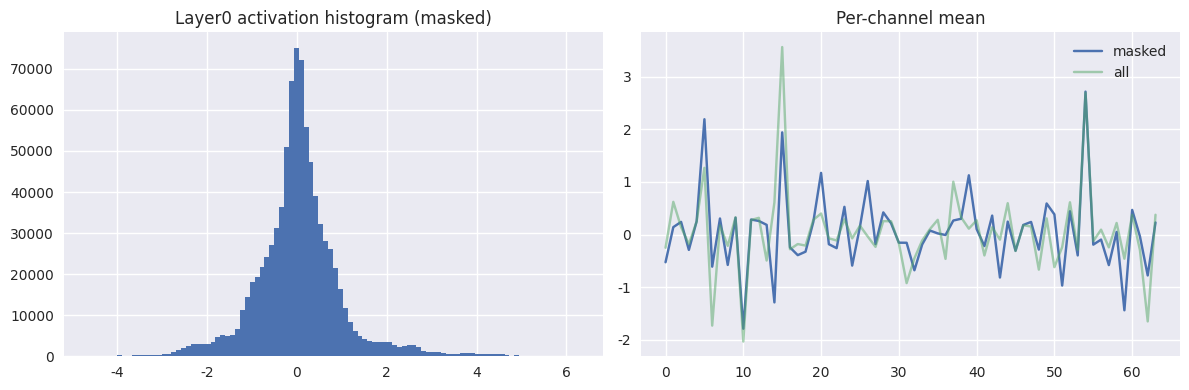

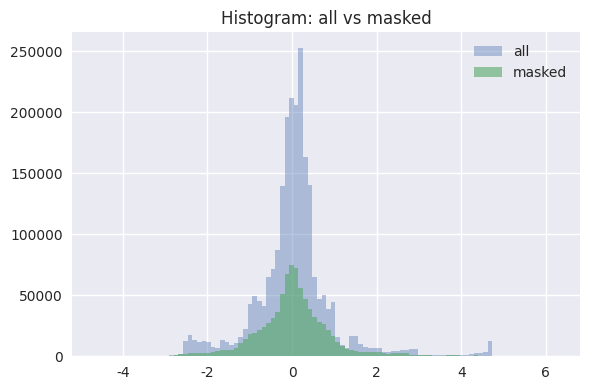

In [14]:
import matplotlib.pyplot as plt
# Capture activations after encoder layer[0]
layer0_out = []

def _hook(module, inp, out):
    # out may be tuple: (hidden_states, residual)
    if isinstance(out, tuple):
        out = out[0]
    layer0_out.append(out.detach().cpu())

print("Hooking module:", type(model.base_model.encoder))
# Prefer hook on first encoder block which is guaranteed to run
hook_handle = model.base_model.encoder.register_forward_hook(_hook)

with torch.no_grad():
    _ = model(x)

hook_handle.remove()

# ===== visualize =====
if len(layer0_out) > 0:
    h = layer0_out[0]   # (B, L, D)

    # Build valid mask from input x: non-padded tokens
    valid_mask = (x.abs().sum(dim=-1) > 0).detach().cpu()  # (B, L)
    n_valid = int(valid_mask.sum().item())
    n_total = int(valid_mask.numel())
    print(f"Valid tokens: {n_valid}/{n_total} ({100.0*n_valid/n_total:.2f}%)")

    # Global stats (unmasked)
    print("mean (all):", h.mean().item())
    print("std  (all):", h.std().item())
    print("min  (all):", h.min().item())
    print("max  (all):", h.max().item())

    # Masked activations (only valid positions)
    h_valid = h[valid_mask]  # (N_valid, D)

    # Global stats (masked)
    print("mean (masked):", h_valid.mean().item())
    print("std  (masked):", h_valid.std().item())
    print("min  (masked):", h_valid.min().item())
    print("max  (masked):", h_valid.max().item())

    # Per-channel mean
    channel_means_all = h.mean(dim=(0, 1)).numpy()
    channel_means_masked = h_valid.mean(dim=0).numpy()

    # Flatten histograms
    h_flat_all = h.reshape(-1).numpy()
    h_flat_masked = h_valid.reshape(-1).numpy()

    # Histograms: masked vs all
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.hist(h_flat_masked, bins=100)
    plt.title("Layer0 activation histogram (masked)")
    plt.subplot(1,2,2)
    plt.plot(channel_means_masked, label="masked")
    plt.plot(channel_means_all, alpha=0.5, label="all")
    plt.title("Per-channel mean")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Optional: overlay hist comparison
    plt.figure(figsize=(6,4))
    plt.hist(h_flat_all, bins=100, alpha=0.4, label="all")
    plt.hist(h_flat_masked, bins=100, alpha=0.6, label="masked")
    plt.legend()
    plt.title("Histogram: all vs masked")
    plt.tight_layout()
    plt.show()
else:
    print("No activations captured.")

In [15]:
# Helper: run classification metrics & t-SNE by split (English messages)
def run_metrics_and_tsne_for_splits(splits=("val",), do_tsne=True):
    split_data = {
        "train": {"X": X_train, "y": y_train, "y_pred": y_pred_train},
        "val":   {"X": X_val,   "y": y_val,   "y_pred": y_pred_val},
        "test":  {"X": X_test,  "y": y_test,  "y_pred": y_pred_test},
    }

    for split in splits:
        if split not in split_data:
            print(f"[Skip] Unknown split: {split}")
            continue

        d = split_data[split]
        y = d["y"]
        y_pred = d["y_pred"]

        print(f"=== {split.upper()}: classification_metrics ===")
        try:
            print(classification_metrics(y, y_pred))
        except Exception as e:
            print(f"[Warn] classification_metrics({split}) failed: {e}")

        if do_tsne:
            try:
                X = d["X"].astype(float)
                _ , _ = tsne_scatter(
                    X,
                    y_true=y,
                    y_score=y_pred,
                    title_left=f"t-SNE colored by true label ({split})",
                    title_right=f"t-SNE colored by model score ({split})",
                )
            except Exception as e:
                print(f"[Warn] t-SNE({split}) failed: {e}")


=== TRAIN: classification_metrics ===
{'precision': 0.6262626262626263, 'recall': 0.8551724137931035, 'f1': 0.7230320699708455, 'auc': 0.7967259721203227, 'pr_auc': 0.839057891668925, 'fpr': 0.524822695035461, 'tpr': 0.8551724137931035, 'R': 0.3303497187576425, 'conf': 1.0, 'threshold': 0.34372392296791077}


/root/miniconda3/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


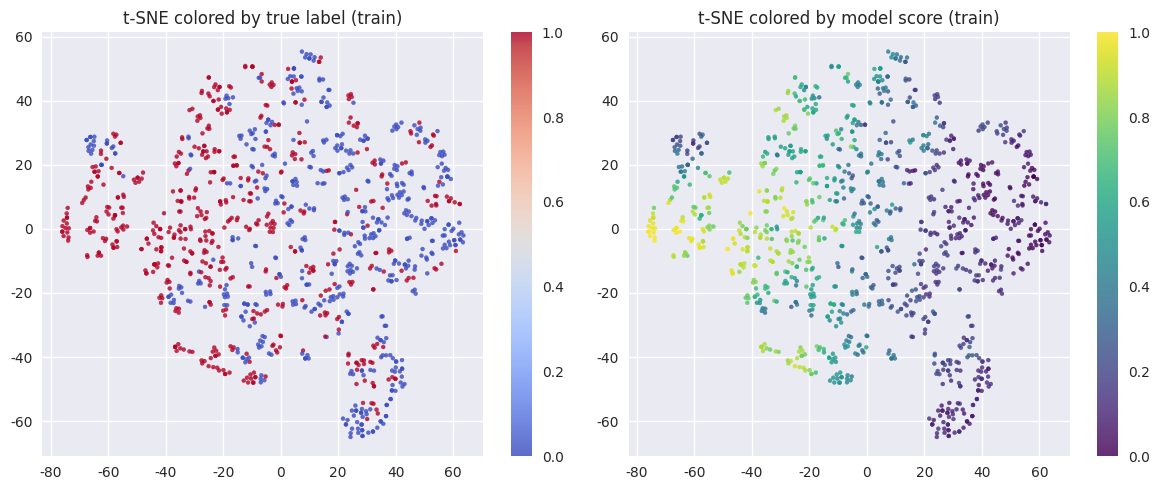

=== VAL: classification_metrics ===
{'precision': 0.7263157894736842, 'recall': 0.8313253012048193, 'f1': 0.7752808988764045, 'auc': 0.7439759036144578, 'pr_auc': 0.7891254121517784, 'fpr': 0.43333333333333335, 'tpr': 0.8313253012048193, 'R': 0.39799196787148594, 'conf': 0.9999999999964262, 'threshold': 0.3546263575553894}


/root/miniconda3/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


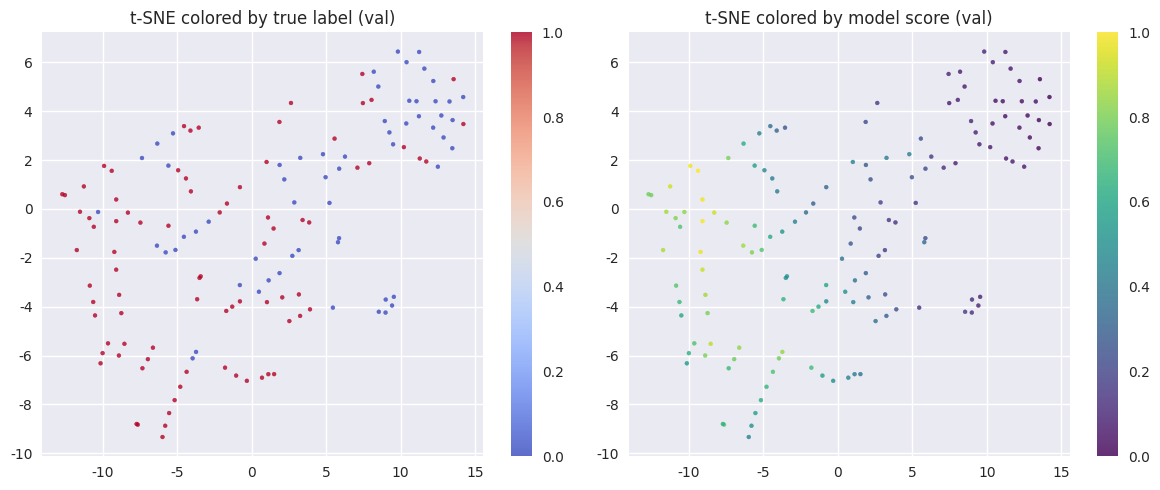

=== TEST: classification_metrics ===
{'precision': 0.5, 'recall': 0.7872340425531915, 'f1': 0.6115702479338843, 'auc': 0.7457890070921985, 'pr_auc': 0.6958720231147616, 'fpr': 0.3854166666666667, 'tpr': 0.7872340425531915, 'R': 0.40181737588652483, 'conf': 0.9999999999955906, 'threshold': 0.34502437710762024}


/root/miniconda3/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


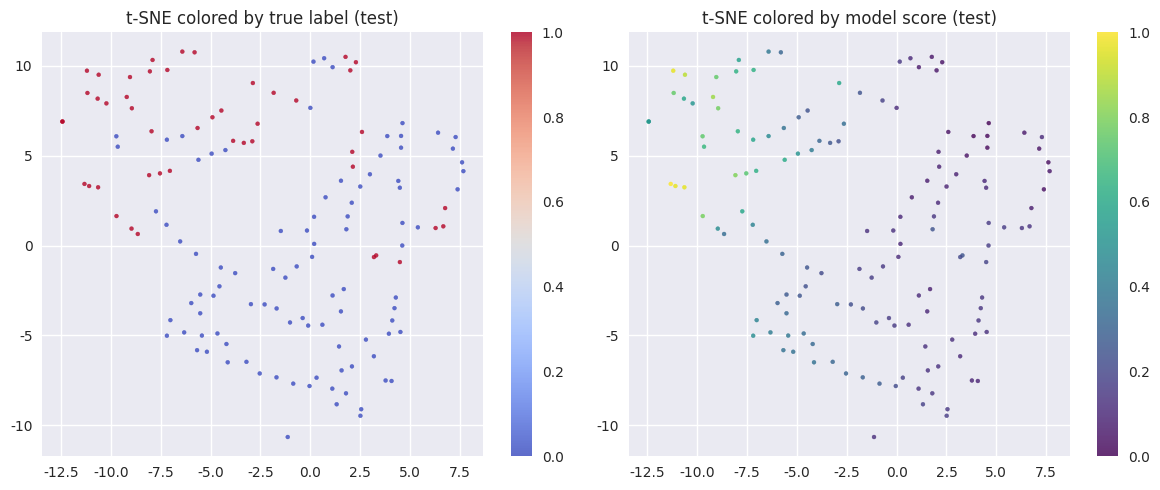

In [16]:
selected_splits = ["train", "val", "test"]
run_metrics_and_tsne_for_splits(selected_splits, do_tsne=True)


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# Train RF on pooled features from original training set
rf = RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1)
rf.fit(X_train, y_train)

# Predict on pooled features from original test set
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# Report metrics for RF predictions on test set
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, digits=4))
print("ROC AUC:", roc_auc_score(y_test, y_proba_rf))

Accuracy: 0.6503496503496503
              precision    recall  f1-score   support

         0.0     0.7805    0.6667    0.7191        96
         1.0     0.4754    0.6170    0.5370        47

    accuracy                         0.6503       143
   macro avg     0.6279    0.6418    0.6281       143
weighted avg     0.6802    0.6503    0.6593       143

ROC AUC: 0.74822695035461


In [18]:
# Normalize RF probabilities for optional plotting/comparison
y_proba_rf_nl = (y_proba_rf - y_proba_rf.min()) / (y_proba_rf.max() - y_proba_rf.min() + 1e-8)

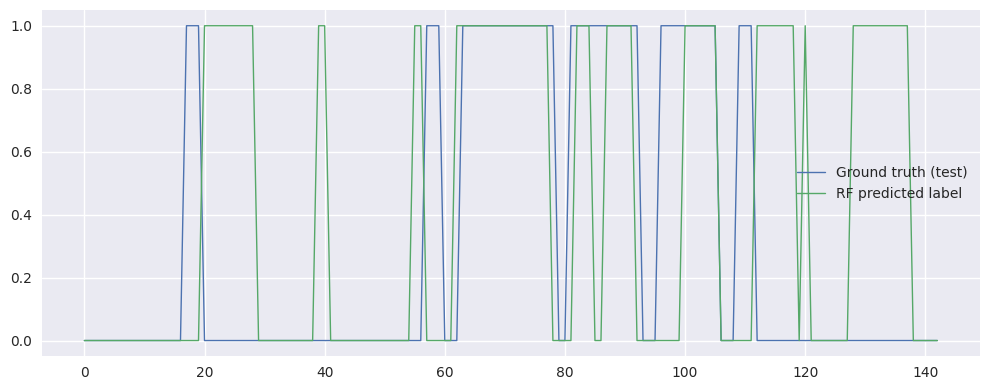

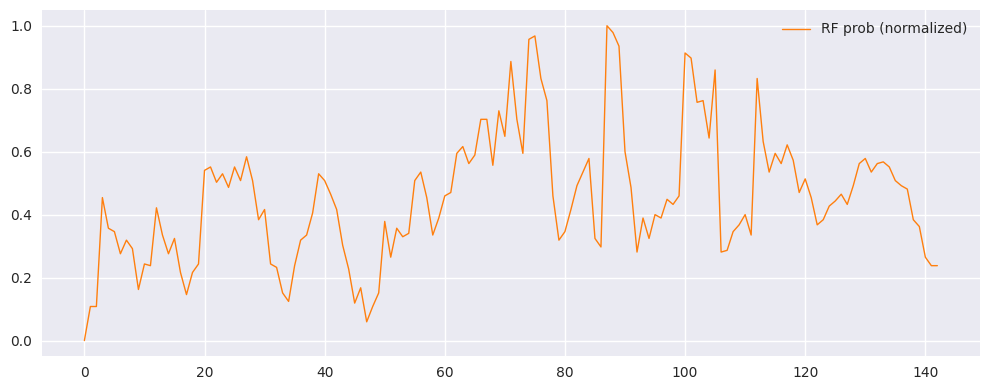

In [19]:
# Visualize ground truth vs RF predicted labels/probabilities on original test set
plt.figure(figsize=(10, 4))
plt.plot(y_test, label="Ground truth (test)", lw=1)
plt.plot(y_pred_rf, label="RF predicted label", lw=1)
plt.legend()
plt.tight_layout()
plt.show()

# Optional: visualize normalized RF probabilities
plt.figure(figsize=(10, 4))
plt.plot(y_proba_rf_nl, label="RF prob (normalized)", color="tab:orange", lw=1)
plt.legend()
plt.tight_layout()
plt.show()

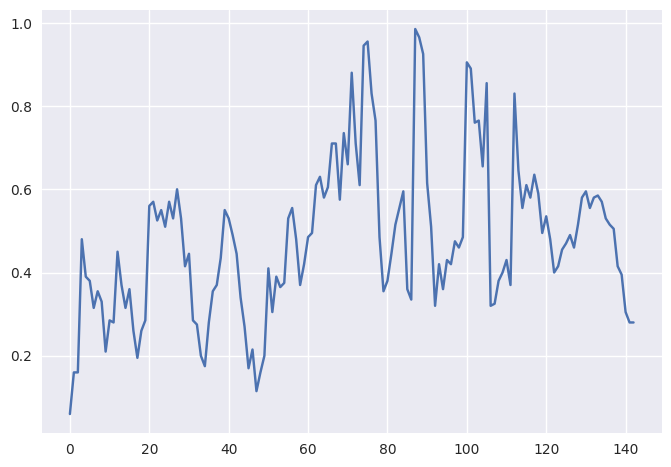

In [20]:
# Quick glance at RF raw probabilities
plt.plot(y_proba_rf)


/root/miniconda3/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


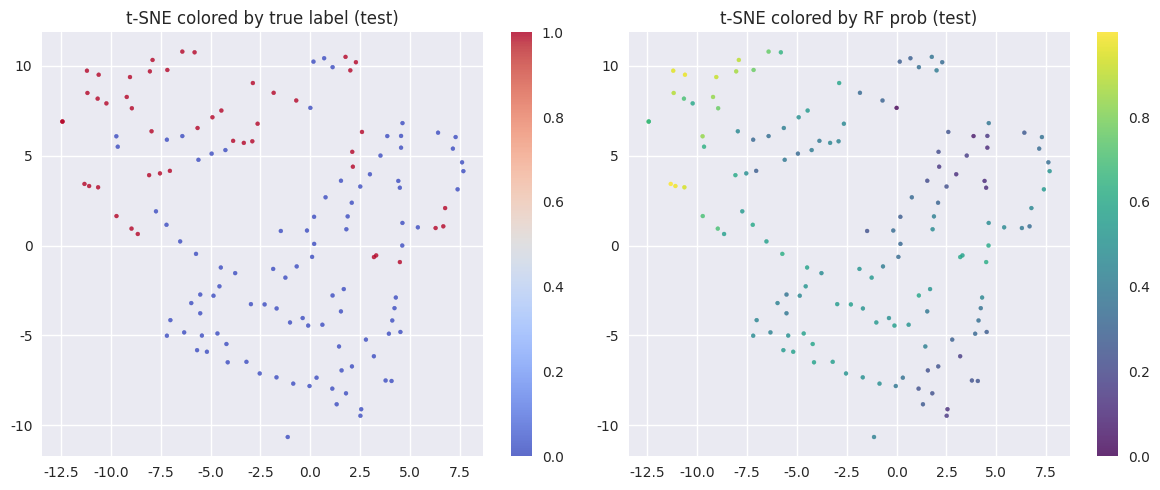

In [21]:
# t-SNE on test features colored by RF probability
# Ensure X_test, y_test, y_proba_rf_nl already computed.
_ , _ = tsne_scatter(
    X_test,
    y_true=y_test,
    y_score=y_proba_rf,
    title_left="t-SNE colored by true label (test)",
    title_right="t-SNE colored by RF prob (test)"
)


In [22]:
# Import reusable Integrated Gradients and plotting helpers
from src.utils.interpretability import integrated_gradients_token_importance, plot_token_importance

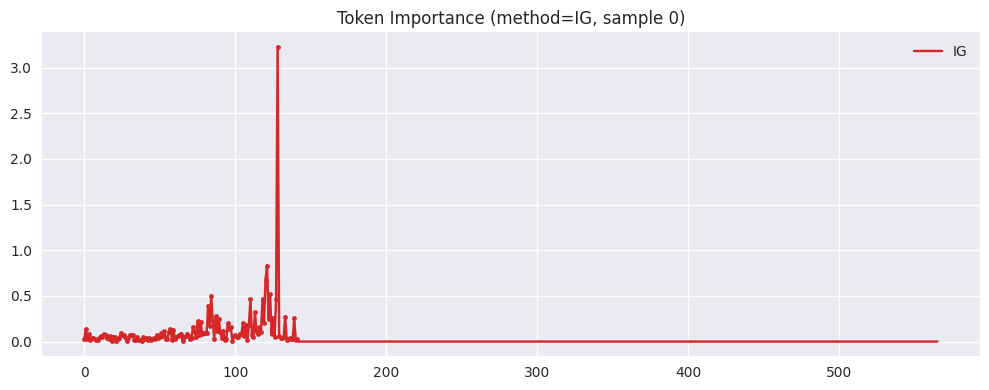

In [23]:
# Example: compute IG token importance and visualize for one sample
# Assumptions:
# - `model` and a batch `x: [B, L, D]` are available
# - `sample_idx` selects which sample to visualize

# Validate prerequisites
try:
    _ = model
    _ = x
except NameError:
    raise RuntimeError("Please define `model` and `x` earlier in the notebook.")

# Compute IG token importance
token_scores_ig = integrated_gradients_token_importance(model=model, x=x, baseline=None, n_steps=40)

# Select a sample for plotting
if 'sample_idx' not in globals():
    sample_idx = 0

# Optional: valid token mask (non-zero features)
valid_mask = (x.abs().sum(dim=-1) > 0)

# Visualize
plot_token_importance(scores=token_scores_ig, sample_idx=sample_idx, label='IG', mask=valid_mask, color='tab:red')